# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Andrian Roby Maulana
- **Email:** cdcc525d6y0200@student.devacademy.id
- **ID Dicoding:** al_faatih_RwpM

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori produk apa yang memiliki total penjualan tertinggi dan terendah di platform e-commerce selama priode 2017-2018, dan bagimana kontribusinya terhadap total revenue?
- **Pertanyaan 2:** Bagaimana tren jumlah order bulanan pada tahun 2017-2018, dan kapan terjadinya penurunan signifikan yang perlu diantisipasi oleh pembisnis?

## Import Semua Packages/Library yang Digunakan

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [48]:
orders = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/orders_dataset.csv')
order_items = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/order_items_dataset.csv')
products = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/products_dataset.csv')
product_category = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/product_category_name_translation.csv')
sellers = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/sellers_dataset.csv')
geolocation = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/geolocation_dataset.csv')
customers = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/customers_dataset.csv')
payments = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/order_payments_dataset.csv')
reviews = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/order_reviews_dataset.csv')

df = df.merge(product_category, on='product_category_name', how='left')

**Insight:** (Opsional)
- Terdapat hubungan antara harga produk (price) dan nilai ongkir (freight_value), di mana produk dengan harga lebih tinggi cenderung memiliki ongkir lebih tinggi.
- Kolom price pada dataset menunjukkan adanya nilai yang sangat tinggi dibandingkan sebagian besar data lainnya.

### Assessing Data

#### Identifying ... problem

In [35]:
# Cek duplicate di dataset lain
print("Duplicate order_items:", order_items.duplicated().sum())
print("Duplicate products:", products.duplicated().sum())

# Cek tipe data semua dataset
print("\nTipe data order_items:")
print(order_items.info())

print("\nTipe data products:")
print(products.info())

# Cek statistik numerik
print("\nStatistik order_items:")
print(order_items.describe())

print("\nStatistik products:")
print(products.describe())

# Cek nilai unik (kategori)
print("\nUnique order_status:")
print(orders['order_status'].value_counts())

# Cek kemungkinan nilai tidak valid
print("\nCek nilai tidak valid:")
print("Harga negatif:", (order_items['price'] < 0).sum())
print("Ongkir negatif:", (order_items['freight_value'] < 0).sum())

# Cek outlier sederhana (range)
print("\nRange harga:")
print("Min:", order_items['price'].min())
print("Max:", order_items['price'].max())

# Cek missing value lebih detail (persentase)
print("\nPersentase Missing Value (orders):")
print((orders.isna().sum() / len(orders)) * 100)

print("\nPersentase Missing Value (products):")
print((products.isna().sum() / len(products)) * 100)

# Cek distribusi kategori produk (top 10)
print("\nTop kategori produk:")
if 'product_category_name' in products.columns:
    print(products['product_category_name'].value_counts().head(10))

orders.info()
order_items.info()
products.info()
customers.info()
payments.info()
reviews.info()

Duplicate order_items: 0
Duplicate products: 0

Tipe data order_items:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
None

Tipe data products:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  o

**Steps to Take:**
- Prioritaskan Top Categories
  -Tingkatkan stok untuk kategori dengan penjualan tertinggi
  - Alokasikan budget iklan lebih besar pada kategori ini
  - Gunakan strategi upselling & cross-selling
- Optimasi Low-Performing Categories
  - Berikan diskon atau bundling produk
  - Evaluasi harga (terlalu mahal / kurang kompetitif)
  - Perbaiki tampilan produk (foto, deskripsi)
- Diversifikasi Produk
  - Tambahkan variasi produk pada kategori yang potensial tapi masih rendah
  - Kurangi ketergantungan pada 1–2 kategori utama

**Insight:** (Opsional)
- Ditemukan adanya data duplikat pada dataset orders, yang menunjukkan bahwa terdapat kemungkinan pencatatan data yang berulang.
- Kolom waktu seperti order_purchase_timestamp masih dalam format string (object) dan belum dalam format datetime.
- Distribusi harga menunjukkan adanya nilai yang sangat tinggi dibandingkan nilai rata-rata (outlier).
- Tidak ditemukan nilai negatif pada kolom harga maupun ongkir.
- Jumlah produk pada setiap kategori tidak seimbang, di mana beberapa kategori memiliki jumlah jauh lebih banyak dibandingkan lainnya.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Cleaning Data

#### Fixing ... problem

In [37]:
orders.drop_duplicates(inplace=True)
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

df = order_items.merge(products, on='product_id', how='left')
df = df.merge(product_category, on='product_category_name', how='left')
df = df.merge(orders[['order_id','order_purchase_timestamp']], on='order_id')
orders = orders.drop_duplicates()
order_items = order_items.drop_duplicates()

df['product_category_name_english'].fillna('unknown', inplace=True)

/tmp/ipykernel_7219/479567303.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['product_category_name_english'].fillna('unknown', inplace=True)


In [ ]:
# Simpan hasil data yang sudah bersih
df.to_csv('cleaned_data.csv', index=False)

**Insight:** (Opsional)
- Proses data cleaning meningkatkan kualitas dataset dengan menghapus data duplikat, mengubah tipe data timestamp menjadi datetime, dan menangani missing value pada kategori produk dengan nilai "unknown".

## Exploratory Data Analysis (EDA)

### Explore ...

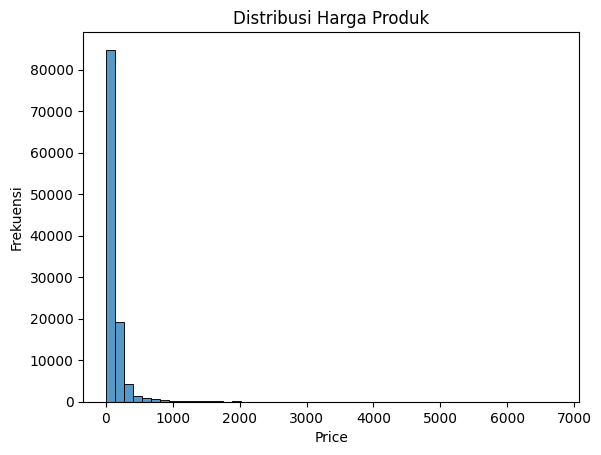


=== Statistik Harga ===
Rata-rata: 120.65373901464716
Median: 74.99
Max: 6735.0
Min: 0.85

=== Top 10 Kategori Produk ===
product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: count, dtype: int64


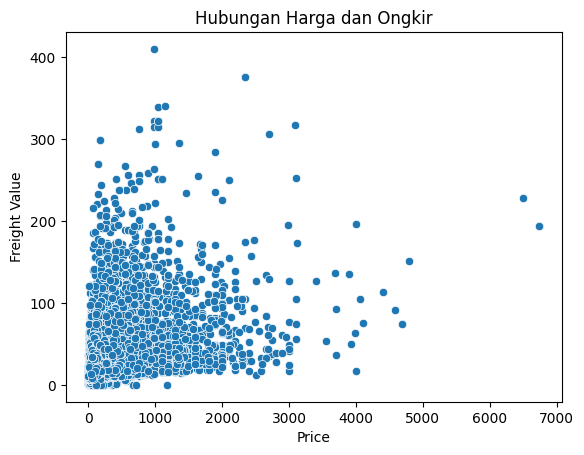

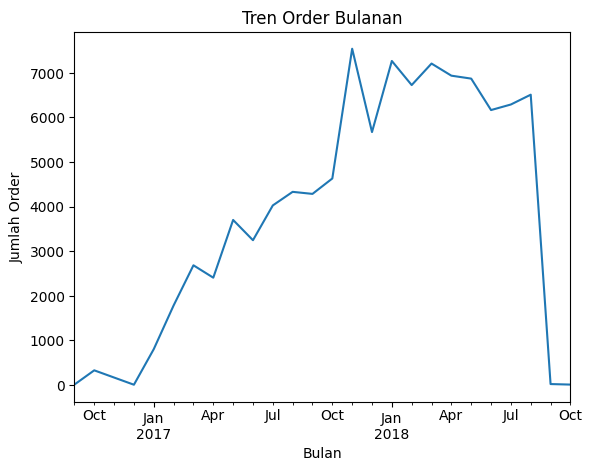

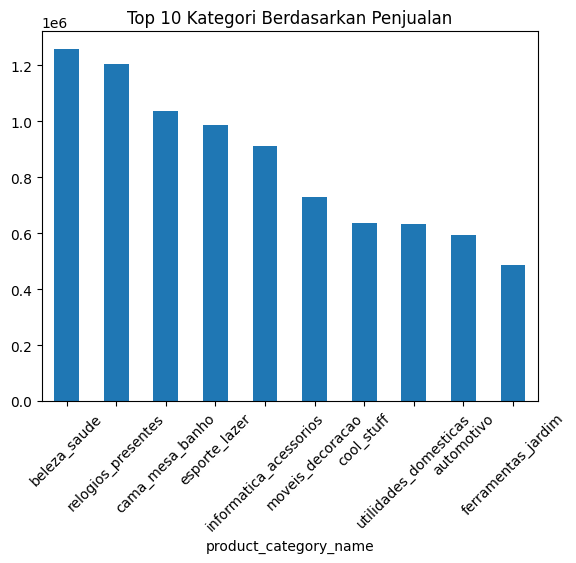

In [ ]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# 1. EDA UNIVARIATE (DISTRIBUSI HARGA)
plt.figure()
sns.histplot(order_items['price'], bins=50)
plt.title("Distribusi Harga Produk")
plt.xlabel("Price")
plt.ylabel("Frekuensi")
plt.show()

# 2. EDA NUMERIK
print("\n=== Statistik Harga ===")
print("Rata-rata:", order_items['price'].mean())
print("Median:", order_items['price'].median())
print("Max:", order_items['price'].max())
print("Min:", order_items['price'].min())

# 3. EDA KATEGORIKAL
print("\n=== Top 10 Kategori Produk ===")
print(products['product_category_name'].value_counts().head(10))

# 4. EDA MULTIVARIATE (HARGA vs ONGKIR)
plt.figure()
sns.scatterplot(x=order_items['price'], y=order_items['freight_value'])
plt.title("Hubungan Harga dan Ongkir")
plt.xlabel("Price")
plt.ylabel("Freight Value")
plt.show()

# 5. EDA TIME SERIES (TREND ORDER)
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = orders.groupby('month')['order_id'].count()

plt.figure()
monthly_orders.plot()
plt.title("Tren Order Bulanan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Order")
plt.show()

# 6. EDA PENJUALAN PER KATEGORI
df_eda = order_items.merge(products, on='product_id', how='left')

category_sales = (
    df_eda.groupby('product_category_name')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
category_sales.plot(kind='bar')
plt.title("Top 10 Kategori Berdasarkan Penjualan")
plt.xticks(rotation=45)
plt.show()

**Insight:** (Opsional)
- Terlihat bahwa jumlah order mengalami peningkatan pada bulan-bulan tertentu, khususnya di akhir tahun. Hal ini menunjukkan adanya pola musiman (seasonality), di mana aktivitas pembelian meningkat pada periode tertentu, kemungkinan dipengaruhi oleh promosi atau event khusus.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

<Axes: xlabel='month'>

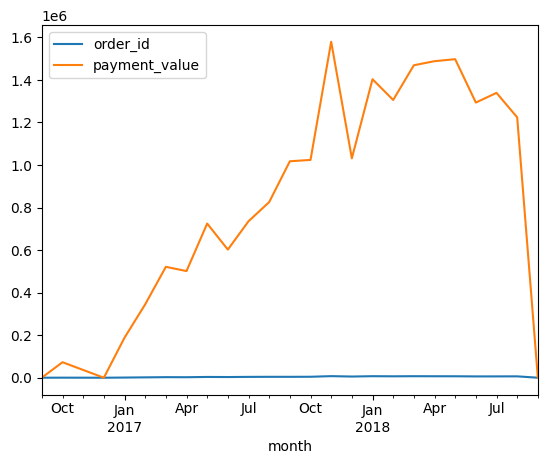

In [45]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly = df.groupby('month').agg({
    'order_id': 'nunique',
    'payment_value': 'sum'
})

monthly.plot()

### Pertanyaan 2:

<Axes: xlabel='product_category_name_english'>

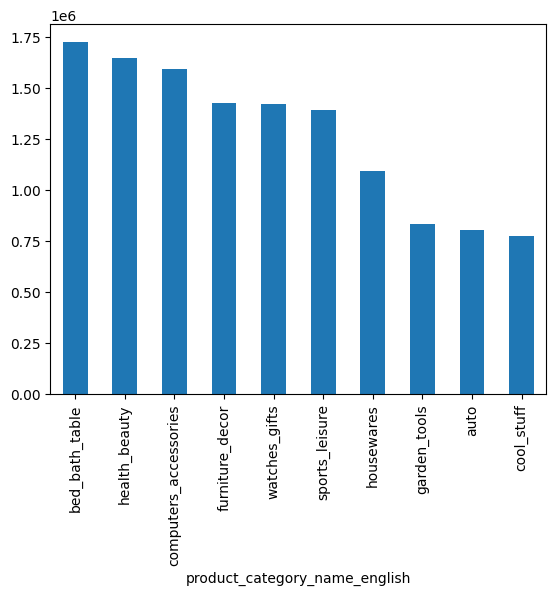

In [49]:
top_category = df.groupby('product_category_name_english')['payment_value'] \
    .sum().sort_values(ascending=False).head(10)

top_category.plot(kind='bar')

**Insight:** (Opsional)
- Jumlah order dan revenue menunjukkan tren meningkat dari awal 2017 hingga pertengahan 2018, dengan puncak terjadi pada bulan November. Hal ini kemungkinan dipengaruhi oleh event promosi seperti Harbolnas atau Black Friday.
- Kategori produk seperti "bed_bath_table" dan "health_beauty" memberikan kontribusi revenue terbesar, menunjukkan bahwa kebutuhan rumah tangga dan perawatan diri memiliki permintaan tinggi.

## Analisis Lanjutan (Opsional)

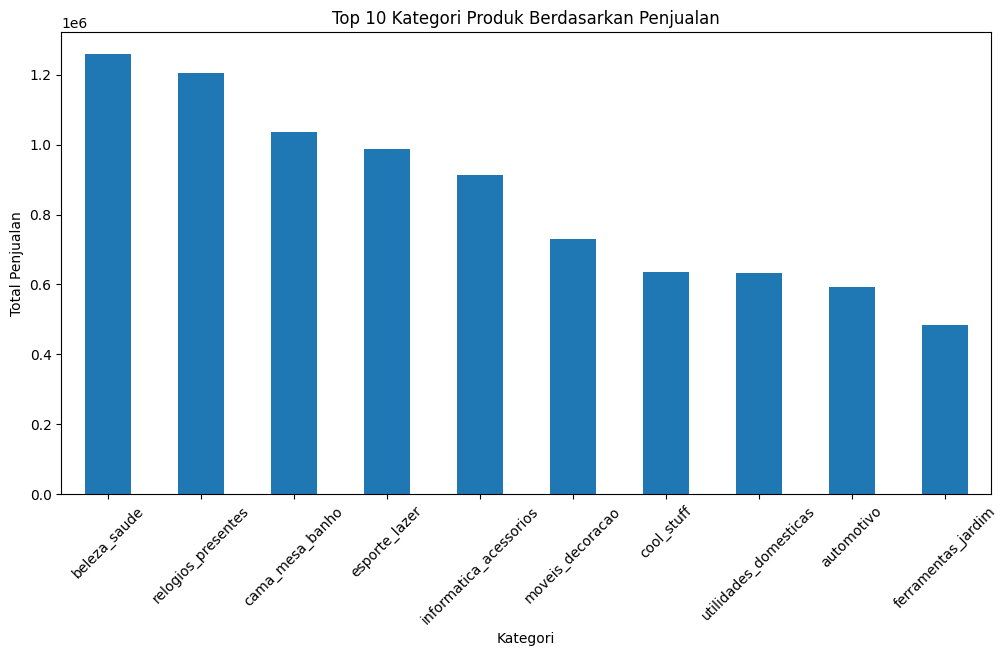

In [ ]:
plt.figure(figsize=(12,6))
category_sales.head(10).plot(kind='bar')
plt.title('Top 10 Kategori Produk Berdasarkan Penjualan')
plt.xlabel('Kategori')
plt.ylabel('Total Penjualan')
plt.xticks(rotation=45)
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Sebagian besar revenue berasl dari sedikit kategori utama, menunjukkan adanya ketimpangan distribusi penjualan antar kategori
- **Conclusion pertanyaan 2:** Terdapat pola musiman pada jumlah order, dengan peningkatan signifikan pada akhir tahun.

**Rekomendasi Action Item:**
- Fokuskan marketing pada kategori top
  - karena terbukti menghasilkan revenue terbesar
- Optimalkan kategori low performance
  - diskon / bundling / repositioning
- Manfaatkan momentum akhir tahun
  - tingkatkan stok & campaign di Q4
- Buat strategi di bulan sepi
  - promo khusus / flash sale

In [ ]:
df.to_csv('main_data_csv')